# Task A: Correlation
Pre-process the data – mean population of each country and mean per capita GDP (from 2001 to 2021) by making some arrangements for the missing values (HINT: You will need to use the datasets Global_GDP.csv and Global_Population.csv). Investigate any correlation between the mean population of each country and the mean per capita GDP (from 2001 to 2021). Very briefly, interpret the generated plot. Evaluate the Pearson Correlation Coefficient.

# Task B: Regression
Perform linear regression, where the independent variable is the mean population of each country (from 2001 to 2021) and dependent variable is mean per capita GDP (from 2001 to 2021). Be prepared to discuss your agreed results during the seminar session.

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats

In [10]:
dfgdp=pd.read_csv("Unit04 Global_GDP.csv")
dfpopulation=pd.read_csv("Unit04 Global_Population.csv")

In [12]:
dfgdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.549721e+09,2.534637e+09,2.727850e+09,2.790849e+09,2.962905e+09,2.983637e+09,3.092430e+09,3.202189e+09,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,1.929944e+10,1.970954e+10,2.147872e+10,2.571501e+10,2.351080e+10,2.679160e+10,...,9.427110e+11,9.498490e+11,9.635600e+11,9.837490e+11,9.186470e+11,8.720230e+11,9.842560e+11,1.011720e+12,1.008380e+12,9.188150e+11
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,5.377778e+08,5.488889e+08,5.466667e+08,7.511112e+08,8.000000e+08,1.006667e+09,...,1.780511e+10,1.990732e+10,2.014640e+10,2.049713e+10,1.913421e+10,1.811656e+10,1.875347e+10,1.805323e+10,1.879945e+10,2.011614e+10
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1.040428e+10,1.112805e+10,1.194335e+10,1.267652e+10,1.383858e+10,1.486247e+10,...,6.709630e+11,7.275710e+11,8.207880e+11,8.514870e+11,7.607300e+11,6.905430e+11,6.837420e+11,7.416920e+11,7.945720e+11,7.845880e+11
4,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.117900e+11,1.280530e+11,1.367100e+11,1.457120e+11,1.161940e+11,1.011240e+11,1.221240e+11,1.013530e+11,8.941719e+10,5.837598e+10


In [13]:
dfpopulation.head()

,Country Name,Country Code,Series Name,Series Code,1960,1961,1962,1963,1964,1965,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54211,55438,56225,56695,57032,57360,...,102560,103159,103774,104341,104872,105366,105845,106314,NaN,NaN
1,Afghanistan,AFG,"Population, total",SP.POP.TOTL,8996967,9169406,9351442,9543200,9744772,9956318,...,31161378,32269592,33370804,34413603,35383028,36296111,37171922,38041757,38928341,39835000
2,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130836765,134159786,137614644,141202036,144920186,148769974,...,547482863,562601578,578075373,593871847,609978946,626392880,643090131,660046272,677243299,694664000
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,96396419,98407221,100506960,102691339,104953470,107289875,...,370243017,380437896,390882979,401586651,412551299,423769930,435229381,446911598,458803476,470898000
4,Albania,ALB,"Population, total",SP.POP.TOTL,1608800,1659800,1711319,1762621,1814135,1864791,...,2900401,2895092,2889104,2880703,2876101,2873457,2866376,2854191,2837743,2832000


Pre-processing the data sets to:
 - only have data between 2001 and 2021
 - deal with null values


In [45]:
gdp_years = [str(year) for year in range(2001, 2021)]
pop_years = [str(year) for year in range(2001, 2021)]

dfgdp_preprocessed = dfgdp[['Country Name'] + gdp_years]
dfpopulation_preprocessed = dfpopulation[['Country Name'] + pop_years]

# Create a new DataFrame with Country Name column
dfgdppercapita = pd.DataFrame()
dfgdppercapita['Country Name'] = dfgdp_preprocessed['Country Name']

for year in pop_years:
    dfpopulation_preprocessed[year] = pd.to_numeric(dfpopulation_preprocessed[year], errors='coerce')

for year in gdp_years:
    dfgdp_preprocessed[year] = pd.to_numeric(dfgdp_preprocessed[year], errors='coerce')

# Calculate GDP per capita for each year
for year in gdp_years:
    # Make sure both DataFrames are aligned by Country Name
    dfgdppercapita[year] = dfgdp_preprocessed[year] / dfpopulation_preprocessed[year]

dfgdppercapita = dfgdppercapita.dropna()
dfpopulation_preprocessed = dfpopulation_preprocessed.dropna()

# Calculate mean GDP per capita across all years
dfgdppercapita['Mean_GDP_Per_Capita'] = dfgdppercapita[gdp_years].mean(axis=1)
dfpopulation_preprocessed['Mean_Population'] = dfpopulation_preprocessed[pop_years].mean(axis=1)

dfgdppercapita.head()




/var/folders/qb/b688h2y51t51sp1bhv6vzdqr0000gn/T/ipykernel_61188/1527553233.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfpopulation_preprocessed[year] = pd.to_numeric(dfpopulation_preprocessed[year], errors='coerce')
/var/folders/qb/b688h2y51t51sp1bhv6vzdqr0000gn/T/ipykernel_61188/1527553233.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfgdp_preprocessed[year] = pd.to_numeric(dfgdp_preprocessed[year], errors='coerce')


,Country Name,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,Mean_GDP_Per_Capita
1,Africa Eastern and Southern,1.197112e+04,1.171234e+04,1.488303e+04,1.773650e+04,1.995371e+04,2.177459e+04,2.438232e+04,2.553372e+04,2.507691e+04,...,3.048161e+04,2.985969e+04,2.947933e+04,2.669430e+04,2.464523e+04,2.711740e+04,2.721732e+04,2.650719e+04,2.360273e+04,2.394725e+04
3,Africa Western and Central,5.393357e+02,6.277726e+02,7.069552e+02,8.545060e+02,1.016475e+03,1.252596e+03,1.430798e+03,1.707273e+03,1.486571e+03,...,1.965117e+03,2.157482e+03,2.178368e+03,1.894311e+03,1.673835e+03,1.613475e+03,1.704140e+03,1.777918e+03,1.710074e+03,1.492343e+03
4,Angola,2.920117e+03,5.010011e+03,5.860183e+03,7.780815e+03,1.227663e+04,1.750382e+04,2.197511e+04,3.004044e+04,2.401595e+04,...,4.415010e+04,4.722130e+04,5.043501e+04,4.033529e+04,3.516010e+04,4.250072e+04,3.535928e+04,3.132838e+04,2.057127e+04,2.708456e+04
5,Albania,1.247031e+02,1.364952e+02,1.739235e+02,2.197679e+02,2.429002e+02,2.644413e+02,3.125042e+02,3.708934e+02,3.408685e+02,...,3.295491e+02,3.349810e+02,3.398483e+02,2.866201e+02,2.924979e+02,3.145675e+02,3.589155e+02,3.577038e+02,3.395046e+02,2.911906e+02
7,Arab World,1.185458e+07,1.146287e+07,1.212986e+07,1.384944e+07,1.645243e+07,1.892487e+07,2.163869e+07,2.687431e+07,2.337043e+07,...,3.310796e+07,3.451182e+07,3.558267e+07,3.143885e+07,3.106229e+07,3.188527e+07,3.529413e+07,3.581780e+07,3.153161e+07,2.569024e+07


In [51]:
# Merge data sets
df_merged = pd.merge(dfgdppercapita[['Country Name', 'Mean_GDP_Per_Capita']], dfpopulation_preprocessed[['Country Name', 'Mean_Population']], on='Country Name', how='inner')

df_merged = df_merged.dropna()
# Calculate correlation
correlation = df_merged['Mean_GDP_Per_Capita'].corr(df_merged['Mean_Population'])
print(f"Pearson Correlation Coefficient: {correlation}")

df_merged.head()



Pearson Correlation Coefficient: 0.210892808454892


,Country Name,Mean_GDP_Per_Capita,Mean_Population
0,Africa Eastern and Southern,2.394725e+04,5.321282e+08
1,Africa Western and Central,1.492343e+03,3.594714e+08
2,Angola,2.708456e+04,2.418655e+07
3,Albania,2.911906e+02,2.935900e+06
4,Arab World,2.569024e+07,3.598853e+08


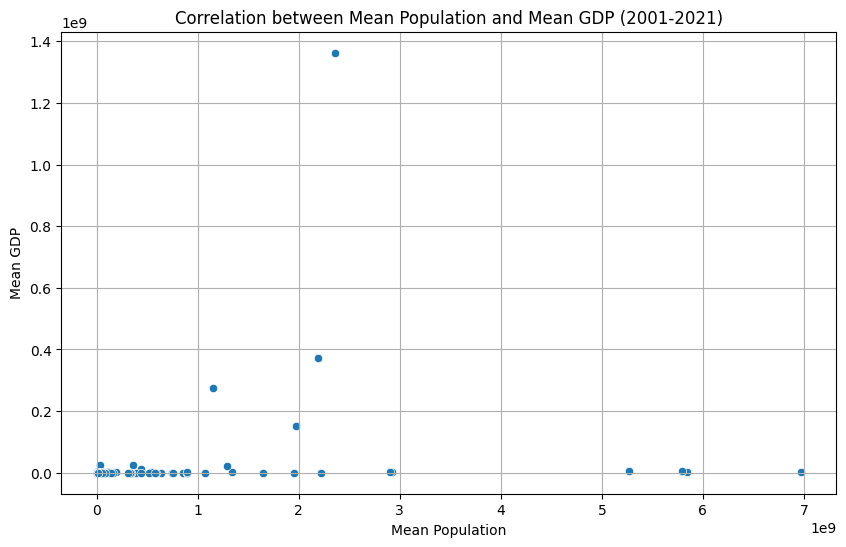

In [52]:
# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Mean_Population', y='Mean_GDP_Per_Capita', data=df_merged)
plt.title('Correlation between Mean Population and Mean GDP (2001-2021)')
plt.xlabel('Mean Population')
plt.ylabel('Mean GDP')
plt.grid(True)
plt.show()

Linear Regression Model: GDP_Per_Capita = 3817184.20 + 0.0223273287 × Population
R-squared: 0.0445


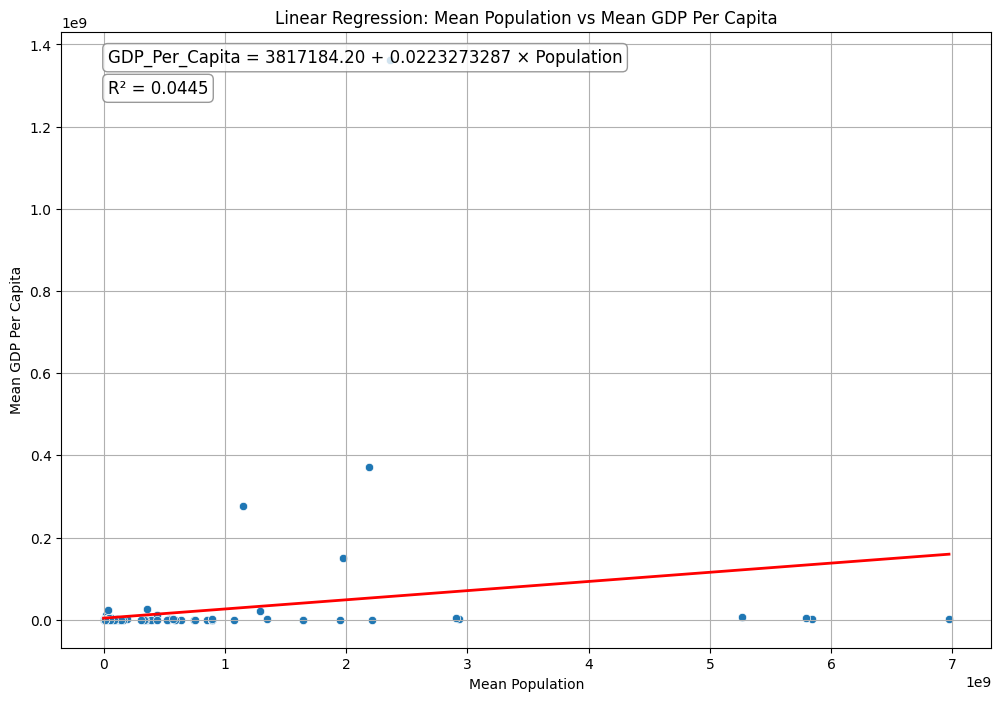

In [56]:
# Prepare data for linear regression
X = df_merged['Mean_Population'].values.reshape(-1, 1)  # Independent variable (reshape for scikit-learn)
y = df_merged['Mean_GDP_Per_Capita'].values  # Dependent variable

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Get model parameters
slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

# Print results
print(f"Linear Regression Model: GDP_Per_Capita = {intercept:.2f} + {slope:.10f} × Population")
print(f"R-squared: {r_squared:.4f}")

# Create prediction line
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred = model.predict(x_range)

# Plot the regression line with the data
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Mean_Population', y='Mean_GDP_Per_Capita', data=df_merged)
plt.plot(x_range, y_pred, color='red', linewidth=2)
plt.title('Linear Regression: Mean Population vs Mean GDP Per Capita')
plt.xlabel('Mean Population')
plt.ylabel('Mean GDP Per Capita')
plt.grid(True)

# Add the equation to the plot
equation = f"GDP_Per_Capita = {intercept:.2f} + {slope:.10f} × Population"
r2_text = f"R² = {r_squared:.4f}"
plt.annotate(equation, xy=(0.05, 0.95), xycoords='axes fraction', fontsize=12, 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
plt.annotate(r2_text, xy=(0.05, 0.90), xycoords='axes fraction', fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.show()

There doesn't seem to be a correlation between Mean Population and Mean GDP per capita